# Imports and configuration

In [1]:
import os

# Reduce CUDA memory fragmentation when training/inferencing with many models and TTA.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import cv2
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import gc
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
from torch.cuda.amp import autocast, GradScaler

In [2]:
# ----------------------------
# Global configuration
# ----------------------------
SEEDS = [42, 2024, 777]  # Multiple seeds to reduce variance via model averaging.
N_FOLDS = 5  # Stratified CV to obtain 5 checkpoints per seed.
IMG_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 20
LR = 1e-4
MIXUP_ALPHA = 0.4  # MixUp strength (alpha in Beta distribution).


def seed_everything(seed: int) -> None:
    """Make training as reproducible as possible across runs."""
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🌱 Seed set to: {seed}")


def find_paths():
    """Centralized dataset path configuration for Kaggle."""
    base_train = "/kaggle/input/dataset/train_data_cleaned"
    test_path = "/kaggle/input/dataset/test_data"
    return {
        "train_img": os.path.join(base_train, "images"),
        "train_mask": os.path.join(base_train, "masks"),
        "labels": os.path.join(base_train, "train_labels.csv"),
        "test_img": os.path.join(test_path, "images"),
        "test_mask": os.path.join(test_path, "masks"),
    }


PATHS = find_paths()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Precompute ROI + color normalization once to speed up training/inference.
PRECOMPUTED_DIR_TRAIN = "/kaggle/working/train_precomputed"
PRECOMPUTED_DIR_TEST = "/kaggle/working/test_precomputed"

# Preprocessing

In [3]:
# ----------------------------
# Preprocessing utilities
# ----------------------------
class ReinhardNormalizer:
    """
    Reinhard color normalization in LAB space:
    match per-channel mean/std to fixed target statistics (reduces stain variability).
    """

    def __init__(self):
        self.target_mean = np.array([148.60, 169.30, 105.47])
        self.target_std = np.array([41.56, 11.23, 14.39])

    def __call__(self, img_rgb):
        try:
            img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype("float32")
            img_mean = np.mean(img_lab, axis=(0, 1))
            img_std = np.std(img_lab, axis=(0, 1)) + 1e-5
            img_lab = (img_lab - img_mean) / img_std * self.target_std + self.target_mean
            img_lab = np.clip(img_lab, 0, 255).astype("uint8")
            return cv2.cvtColor(img_lab, cv2.COLOR_LAB2RGB)
        except:
            # Fail-safe: if any conversion fails, keep the original image.
            return img_rgb


def get_bbox_from_mask(mask):
    """Return (ymin, ymax, xmin, xmax) bounding box for positive pixels; None if empty."""
    if np.sum(mask) == 0:
        return None
    rows, cols = np.where(mask > 0)
    return np.min(rows), np.max(rows), np.min(cols), np.max(cols)


def preprocess_and_save_batch(df, src_img_dir, src_mask_dir, output_dir, is_test=False):
    """
    Offline preprocessing:
    1) load image (+ optional mask),
    2) crop to ROI bbox from mask (if available),
    3) Reinhard normalize,
    4) resize to IMG_SIZE and save.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    reinhard = ReinhardNormalizer()
    valid_files = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Precomputing"):
        img_name = row["filename"] if is_test else row["sample_index"]
        mask_name = (
            img_name.replace("img", "mask") if "img" in img_name else img_name.replace(".png", "_mask.png")
        )

        img_p = os.path.join(src_img_dir, img_name)
        mask_p = os.path.join(src_mask_dir, mask_name)
        out_p = os.path.join(output_dir, img_name)

        # Skip already processed files (useful when re-running the notebook).
        if os.path.exists(out_p):
            valid_files.append(img_name)
            continue

        try:
            image = cv2.imread(img_p)
            if image is None:
                continue
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # ROI crop driven by the provided segmentation mask (background removal).
            if os.path.exists(mask_p):
                mask = cv2.imread(mask_p, cv2.IMREAD_GRAYSCALE)
                if mask is not None:
                    bbox = get_bbox_from_mask(mask)
                    if bbox:
                        image = image[bbox[0]: bbox[1] + 1, bbox[2]: bbox[3] + 1]

            image = reinhard(image)
            Image.fromarray(image).resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS).save(out_p, "PNG")
            valid_files.append(img_name)
        except:
            # Keep preprocessing robust: skip problematic samples rather than crashing.
            continue

    return valid_files


class TissueDataset(Dataset):
    """Dataset that reads from precomputed PNGs and applies fast PyTorch transforms."""

    def __init__(self, dataframe, precomputed_dir, transform=None, is_test=False):
        self.df = dataframe
        self.precomputed_dir = precomputed_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row["filename"] if self.is_test else row["sample_index"]
        img_path = os.path.join(self.precomputed_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            # Fallback image for rare I/O issues; keeps batch shapes consistent.
            image = Image.new("RGB", (IMG_SIZE, IMG_SIZE))

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, img_name
        return image, torch.tensor(row["label_encoded"], dtype=torch.long)


def get_transforms():
    """Train-time augmentation and standard ImageNet normalization for pretrained backbones."""
    train = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
        AutoAugment(policy=AutoAugmentPolicy.IMAGENET),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train, val

In [4]:
# ----------------------------
# MixUp regularization
# ----------------------------
def mixup_data(x, y, alpha=1.0):
    """Classic MixUp: convex combination of two samples and their labels."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(DEVICE)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Loss for MixUp with classification criterion."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


def get_model(num_classes):
    """EfficientNet-B0 backbone (ImageNet pretrained) with a task-specific classifier head."""
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model.to(DEVICE)

# Training

In [5]:
# ----------------------------
# Training (one seed, K-fold CV)
# ----------------------------
def train_one_seed(seed, df_final, le, precomputed_dir):
    seed_everything(seed)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

    histories = []
    all_targets, all_preds = [], []

    for fold, (t_idx, v_idx) in enumerate(skf.split(df_final, df_final["label_encoded"])):
        print(f"\n--- Seed {seed} | Fold {fold + 1}/{N_FOLDS} ---")
        train_df = df_final.iloc[t_idx].reset_index(drop=True)
        val_df = df_final.iloc[v_idx].reset_index(drop=True)

        # Weighted sampling to reduce class imbalance effects inside each minibatch.
        counts = train_df["label_encoded"].value_counts().sort_index().values
        weights = 1.0 / counts
        s_weights = [weights[l] for l in train_df["label_encoded"]]
        sampler = WeightedRandomSampler(s_weights, len(s_weights))

        train_loader = DataLoader(
            TissueDataset(train_df, precomputed_dir, get_transforms()[0]),
            batch_size=BATCH_SIZE,
            sampler=sampler,
            num_workers=2,
        )
        val_loader = DataLoader(
            TissueDataset(val_df, precomputed_dir, get_transforms()[1]),
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
        )

        model = get_model(len(le.classes_))
        optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
        criterion = nn.CrossEntropyLoss()
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
        scaler = GradScaler()

        best_f1 = 0.0
        fold_hist = {"t_loss": [], "v_loss": [], "v_f1": []}

        for epoch in range(EPOCHS):
            model.train()
            t_loss = 0.0

            for imgs, lbls in tqdm(train_loader, desc=f"Ep {epoch + 1}", leave=False):
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                optimizer.zero_grad()

                # AMP speeds up training and reduces GPU memory usage.
                with autocast():
                    imgs, ta, tb, lam = mixup_data(imgs, lbls, MIXUP_ALPHA)
                    out = model(imgs)
                    loss = mixup_criterion(criterion, out, ta, tb, lam)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                t_loss += loss.item()

            scheduler.step()

            # Validation (no MixUp).
            model.eval()
            v_loss = 0.0
            v_preds, v_targets = [], []

            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                    with autocast():
                        out = model(imgs)
                        loss = criterion(out, lbls)
                    v_loss += loss.item()
                    v_preds.extend(out.argmax(1).cpu().numpy())
                    v_targets.extend(lbls.cpu().numpy())

            t_loss /= max(1, len(train_loader))
            v_loss /= max(1, len(val_loader))
            f1 = f1_score(v_targets, v_preds, average="macro")

            print(f"Ep {epoch + 1}: T_Loss {t_loss:.4f} | V_Loss {v_loss:.4f} | Val F1 {f1:.4f}")
            fold_hist["t_loss"].append(t_loss)
            fold_hist["v_loss"].append(v_loss)
            fold_hist["v_f1"].append(f1)

            # Save the best checkpoint per fold (used later for ensembling).
            if f1 > best_f1:
                best_f1 = f1
                torch.save(model.state_dict(), f"b0_seed{seed}_fold{fold}.pth")

        print(f"🏆 Best F1 Fold {fold + 1}: {best_f1:.4f}")
        histories.append(fold_hist)

        # Out-of-fold evaluation using the best checkpoint (for diagnostics).
        model.load_state_dict(torch.load(f"b0_seed{seed}_fold{fold}.pth"))
        model.eval()
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs = imgs.to(DEVICE)
                out = model(imgs)
                all_preds.extend(out.argmax(1).cpu().numpy())
                all_targets.extend(lbls.cpu().numpy())

        del model, optimizer, scaler
        torch.cuda.empty_cache()
        gc.collect()

    return histories, all_targets, all_preds

In [6]:
# ----------------------------
# Plots (per seed)
# ----------------------------
def plot_seed_results(histories, all_targets, all_preds, le, seed_name):
    """Visualize learning curves and aggregated confusion matrix for one seed."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for i, h in enumerate(histories):
        axes[0].plot(h["t_loss"], linestyle="--", alpha=0.4, label=f"F{i + 1} Train")
        axes[0].plot(h["v_loss"], linewidth=2, label=f"F{i + 1} Val")
        axes[1].plot(h["v_f1"], linewidth=2, label=f"F{i + 1} F1")

    axes[0].set_title(f"Loss Curves (Seed {seed_name})")
    axes[1].set_title(f"Val F1 (Seed {seed_name})")
    axes[0].grid(True, alpha=0.3)
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f"Global Confusion Matrix (Seed {seed_name})")
    plt.ylabel("True Label")
    plt.xlabel("Pred")
    plt.show()

## Submission

In [7]:
# ----------------------------
# Submission helper (ensemble + 4-view TTA)
# ----------------------------
def generate_submission(df, le):
    """Generate submission using an ensemble across seeds/folds and simple geometric TTA."""
    print("\n--- Generating Submission with Seed Averaging ---")

    test_files = sorted([f for f in os.listdir(PATHS["test_img"]) if f.endswith(".png")])
    test_df = pd.DataFrame({"filename": test_files})

    valid_test = preprocess_and_save_batch(
        test_df, PATHS["test_img"], PATHS["test_mask"], PRECOMPUTED_DIR_TEST, is_test=True
    )
    test_df = test_df[test_df["filename"].isin(valid_test)].reset_index(drop=True)

    test_ds = TissueDataset(test_df, PRECOMPUTED_DIR_TEST, get_transforms()[1], is_test=True)
    loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    # Load all fold checkpoints from all seeds (model-level ensembling).
    all_models = []
    for seed in SEEDS:
        for fold in range(N_FOLDS):
            path = f"b0_seed{seed}_fold{fold}.pth"
            if os.path.exists(path):
                m = get_model(len(le.classes_))
                m.load_state_dict(torch.load(path))
                m.eval()
                all_models.append(m)

    print(f"📦 Loaded {len(all_models)} models for Ensemble.")

    preds, fnames = [], []
    with torch.no_grad():
        for imgs, names in tqdm(loader, desc="Inference"):
            imgs = imgs.to(DEVICE)

            # 4-view TTA: original, H-flip, V-flip, and 90-degree rotation.
            inputs = [imgs, torch.flip(imgs, [3]), torch.flip(imgs, [2]), torch.rot90(imgs, 1, [2, 3])]
            avg_probs = torch.zeros((imgs.size(0), len(le.classes_))).to(DEVICE)

            for m in all_models:
                for x in inputs:
                    with autocast():
                        avg_probs += torch.softmax(m(x), dim=1)

            avg_probs /= (len(all_models) * len(inputs))
            preds.extend(le.inverse_transform(avg_probs.argmax(1).cpu().numpy()))
            fnames.extend(names)

    pd.DataFrame({"sample_index": fnames, "label": preds}).to_csv("submission.csv", index=False)
    print("✅ Done! Submission saved.")

# Main

Precomputing: 100%|██████████| 581/581 [01:23<00:00,  6.95it/s]
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


🌱 Seed set to: 42

--- Seed 42 | Fold 1/5 ---


100%|██████████| 20.5M/20.5M [00:00<00:00, 132MB/s] 
/tmp/ipykernel_20/481633779.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Ep 1:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 1: T_Loss 1.4023 | V_Loss 1.3823 | Val F1 0.2041


Ep 2:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Ep 18: T_Loss 1.2077 | V_Loss 1.3785 | Val F1 0.3200


Ep 19:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 19: T_Loss 1.2050 | V_Loss 1.3784 | Val F1 0.3051


Ep 20:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 20: T_Loss 1.2241 | V_Loss 1.3879 | Val F1 0.3054
🏆 Best F1 Fold 5: 0.3200

📊 Results for Seed 42:


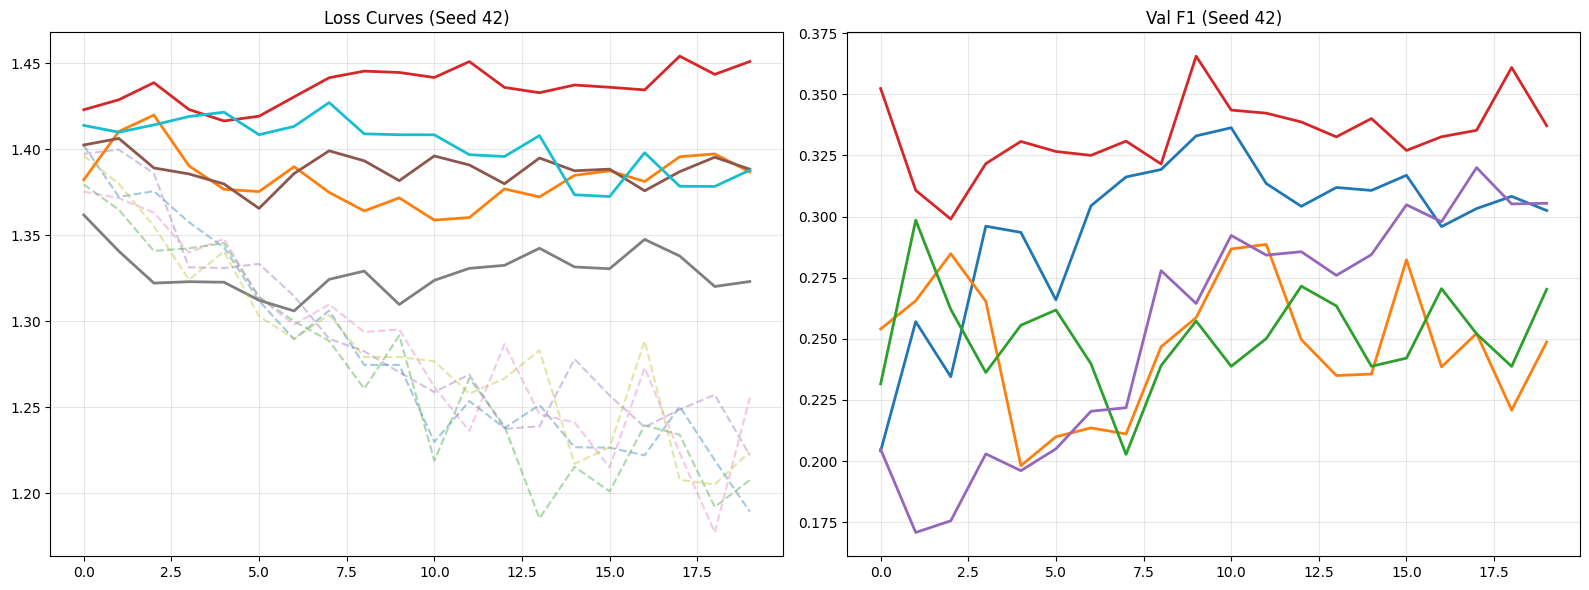

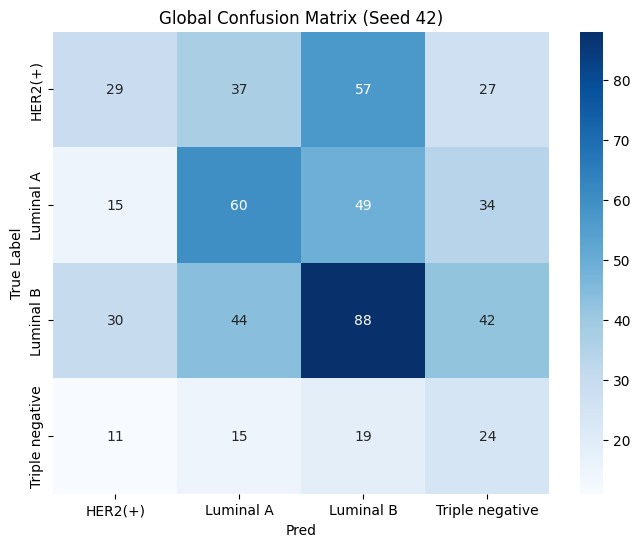

/tmp/ipykernel_20/481633779.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🌱 Seed set to: 2024

--- Seed 2024 | Fold 1/5 ---


Ep 1:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 1: T_Loss 1.3923 | V_Loss 1.3658 | Val F1 0.2616


Ep 2:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Ep 18: T_Loss 1.2437 | V_Loss 1.3629 | Val F1 0.3252


Ep 19:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 19: T_Loss 1.2503 | V_Loss 1.3630 | Val F1 0.3458


Ep 20:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 20: T_Loss 1.2482 | V_Loss 1.3627 | Val F1 0.3422
🏆 Best F1 Fold 5: 0.3618

📊 Results for Seed 2024:


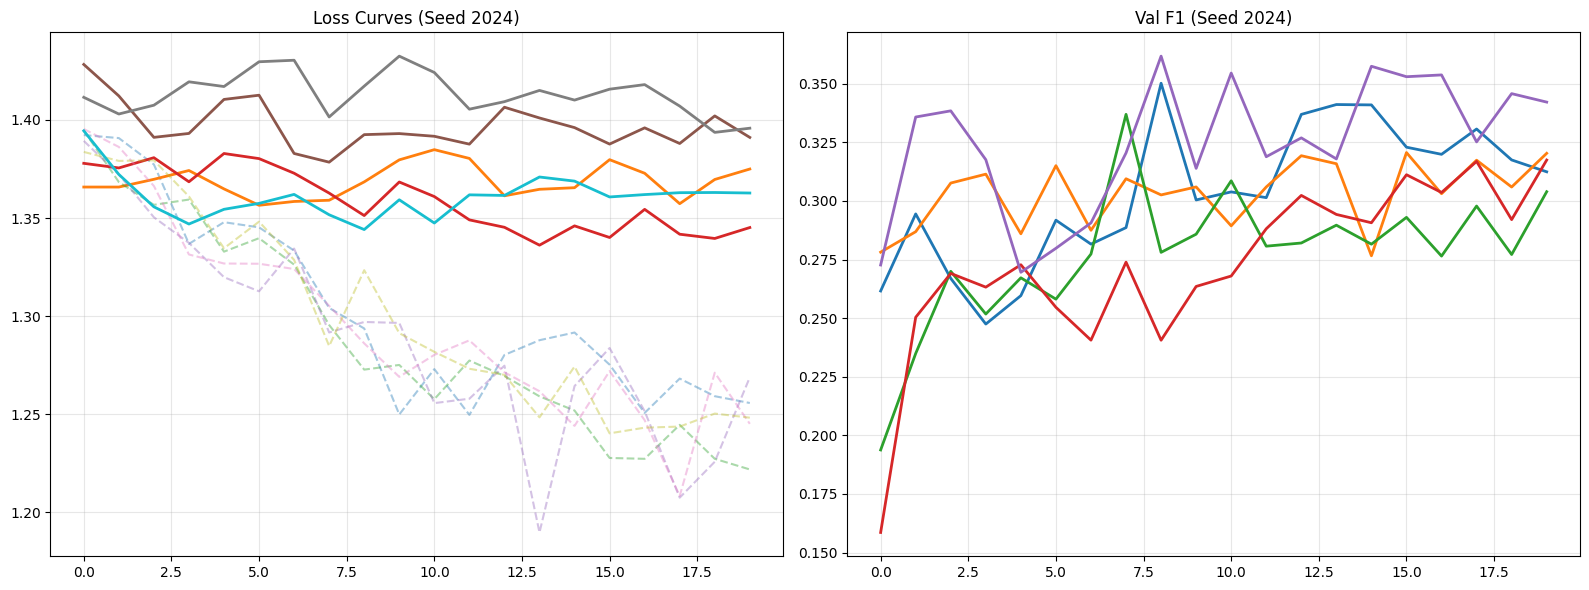

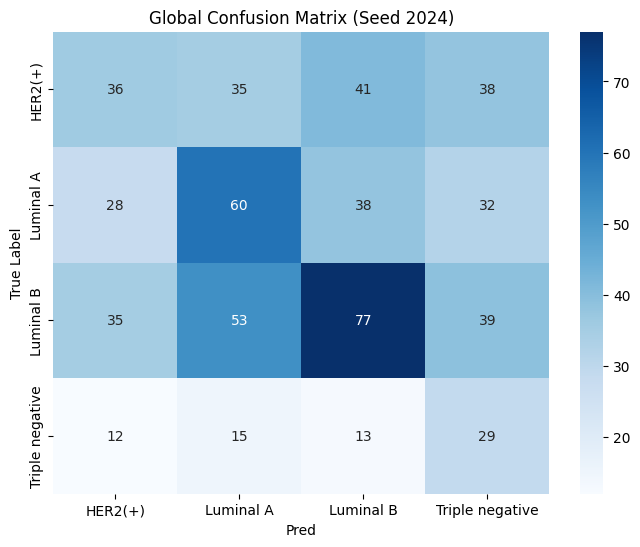

/tmp/ipykernel_20/481633779.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


🌱 Seed set to: 777

--- Seed 777 | Fold 1/5 ---


Ep 1:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 1: T_Loss 1.3886 | V_Loss 1.3752 | Val F1 0.2819


Ep 2:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Ep 18: T_Loss 1.2194 | V_Loss 1.3386 | Val F1 0.3169


Ep 19:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 19: T_Loss 1.2043 | V_Loss 1.3396 | Val F1 0.3296


Ep 20:   0%|          | 0/15 [00:00<?, ?it/s]/tmp/ipykernel_20/481633779.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_20/481633779.py:73: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Ep 20: T_Loss 1.2340 | V_Loss 1.3361 | Val F1 0.3231
🏆 Best F1 Fold 5: 0.3296

📊 Results for Seed 777:


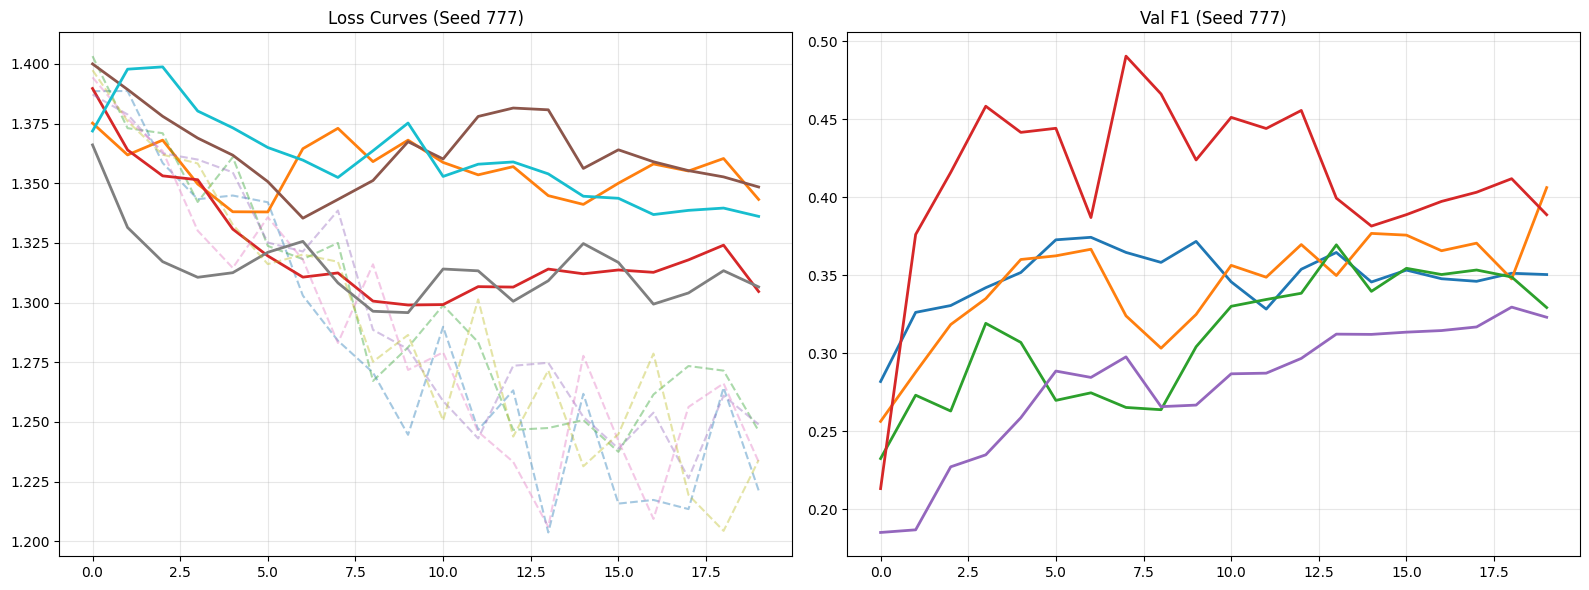

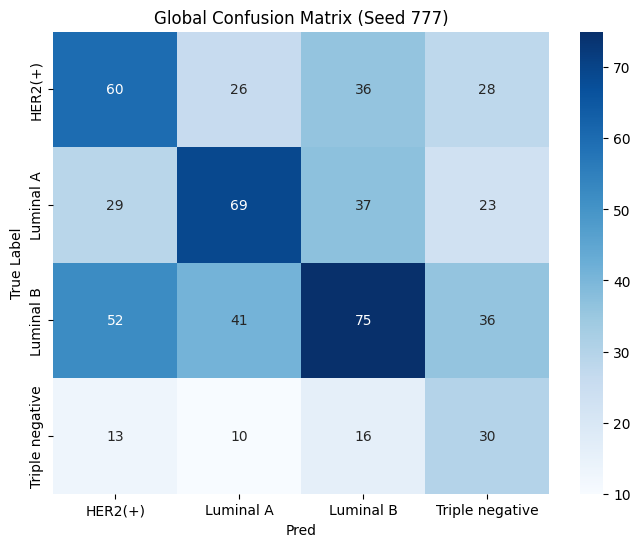

In [8]:
# ----------------------------
# Main execution
# ----------------------------
if __name__ == "__main__":
    df = pd.read_csv(PATHS["labels"])

    # Keep only samples whose image files are available.
    valid_mask = df["sample_index"].apply(lambda x: os.path.exists(os.path.join(PATHS["train_img"], x)))
    df = df[valid_mask].reset_index(drop=True)

    # Encode string labels to integers for CrossEntropyLoss.
    le = LabelEncoder()
    df["label_encoded"] = le.fit_transform(df["label"])

    # One-time preprocessing for the full training set (shared across all seeds/folds).
    valid_train = preprocess_and_save_batch(df, PATHS["train_img"], PATHS["train_mask"], PRECOMPUTED_DIR_TRAIN)
    df_final = df[df["sample_index"].isin(valid_train)].reset_index(drop=True)

    # Train K-fold models for each seed, then plot per-seed diagnostics.
    for seed in SEEDS:
        h, t, p = train_one_seed(seed, df_final, le, PRECOMPUTED_DIR_TRAIN)
        print(f"\n📊 Results for Seed {seed}:")
        plot_seed_results(h, t, p, le, seed)

In [9]:
# ----------------------------
# Standalone submission cell (ensemble + TTA)
# ----------------------------
print("\nGenerating Submission with TTA (4 Views)...")

test_files = sorted([f for f in os.listdir(PATHS["test_img"]) if f.endswith(".png")])
test_df = pd.DataFrame({"filename": test_files})

valid_test_files = preprocess_and_save_batch(
    test_df, PATHS["test_img"], PATHS["test_mask"], PRECOMPUTED_DIR_TEST, is_test=True
)

test_df = test_df[test_df["filename"].isin(valid_test_files)].reset_index(drop=True)
test_ds = TissueDataset(test_df, PRECOMPUTED_DIR_TEST, get_transforms()[1], is_test=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

models_list = []
print("Loading models for Ensemble...")
for seed in SEEDS:
    for fold in range(N_FOLDS):
        path = f"b0_seed{seed}_fold{fold}.pth"
        if os.path.exists(path):
            m = get_model(len(le.classes_))
            m.load_state_dict(torch.load(path))
            m.eval()
            models_list.append(m)

print(f"Loaded {len(models_list)} models.")

final_preds = []
final_names = []

with torch.no_grad():
    for imgs, names in tqdm(test_loader, desc="Inference TTA"):
        imgs = imgs.to(DEVICE)

        # Average probabilities over models and geometric views (simple, robust TTA).
        avg_probs = torch.zeros((imgs.size(0), len(le.classes_))).to(DEVICE)

        for m in models_list:
            p1 = torch.softmax(m(imgs), dim=1)
            p2 = torch.softmax(m(torch.flip(imgs, [3])), dim=1)
            p3 = torch.softmax(m(torch.flip(imgs, [2])), dim=1)
            p4 = torch.softmax(m(torch.rot90(imgs, 1, [2, 3])), dim=1)
            avg_probs += (p1 + p2 + p3 + p4) / 4.0

        avg_probs /= len(models_list)

        pred_idxs = avg_probs.argmax(1).cpu().numpy()
        final_preds.extend(le.inverse_transform(pred_idxs))
        final_names.extend(names)

submission = pd.DataFrame({"sample_index": final_names, "label": final_preds})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved: {len(submission)} rows.")


Generating Submission with TTA (4 Views)...


Precomputing: 100%|██████████| 477/477 [01:14<00:00,  6.41it/s]


Loading models for Ensemble...
Loaded 15 models.


Inference TTA: 100%|██████████| 15/15 [00:42<00:00,  2.84s/it]

Submission saved: 477 rows.
